✅ DataFrame prêt : 2625 lignes, 8 colonnes

=== Croisement 1 — Concentration de l'offre ===


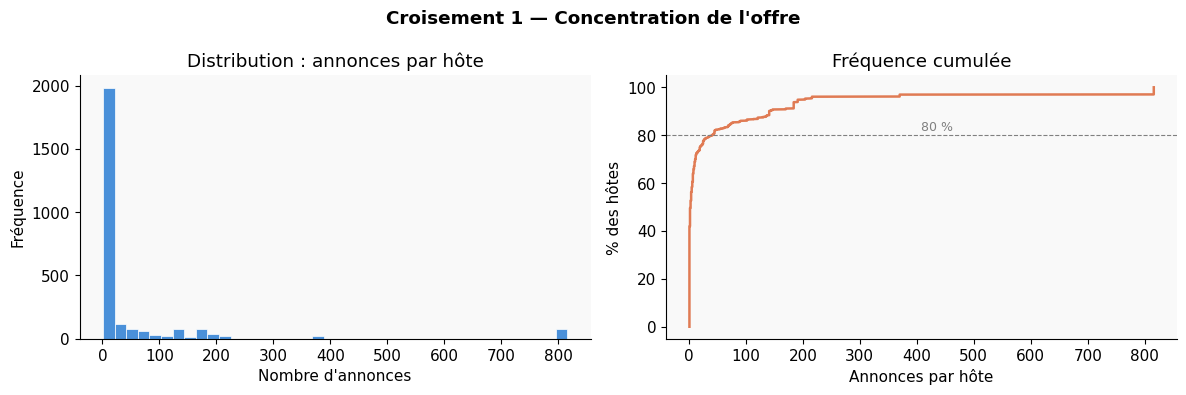

  Médiane : 3.0 annonces/hôte
  Max     : 816 annonces/hôte
  Hôtes avec > 1 annonce : 58.1%
LIMITES : un hôte multi-annonces n'est pas forcément une agence.

=== Croisement 2 — Disponibilité × Score catalogue ===


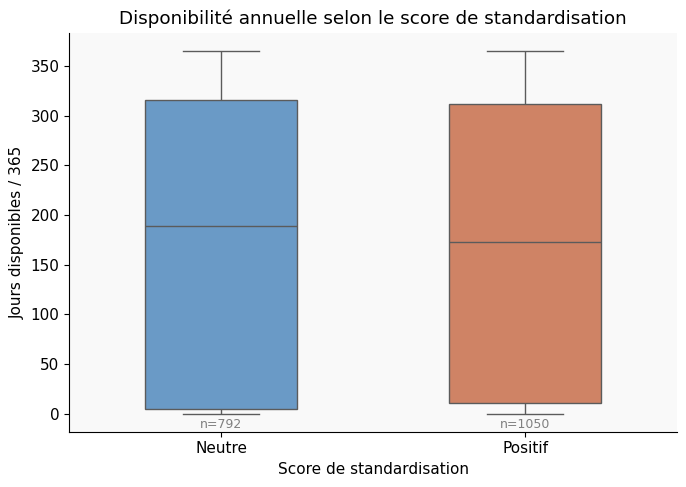

  Médiane disponibilité — Neutre : 188.5 jours
  Médiane disponibilité — Positif : 172.5 jours
LIMITES : un facteur commun (type de bien) peut expliquer les deux.

=== Croisement 3 — Réactivité × Nombre d'annonces ===


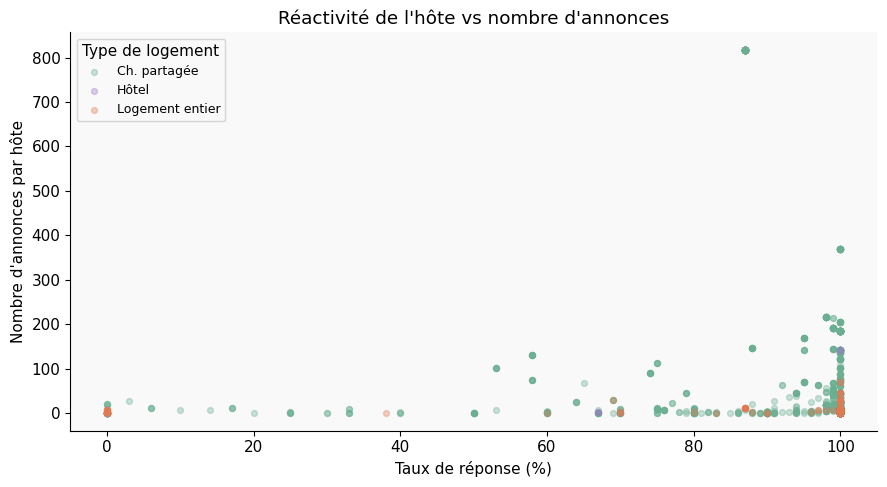

LIMITES : les plateformes imposent des délais stricts indépendamment
  du nb d'annonces — facteur commun possible.

=== Croisement 4 — Type de logement × Impact quartier ===


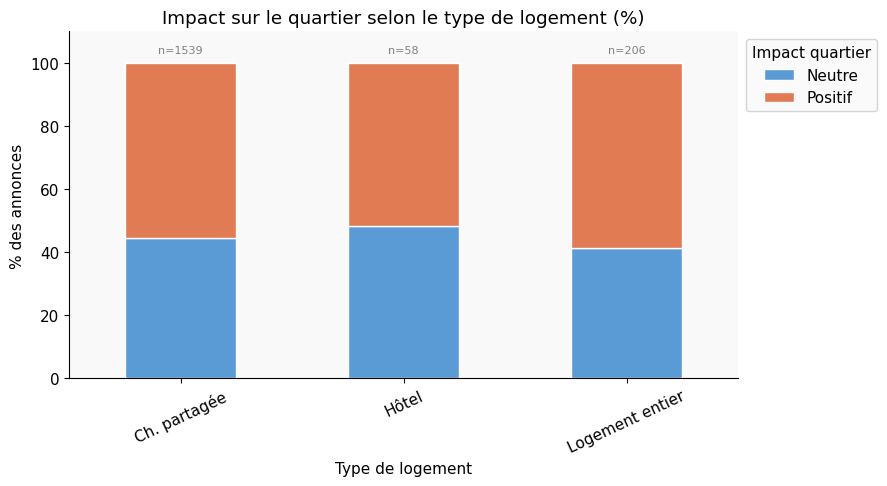

LIMITES : le score mesure le discours de l'hôte, pas l'impact réel
  sur les loyers ou la population du quartier.

=== Croisement 5 — Délai de réponse × Type de logement ===


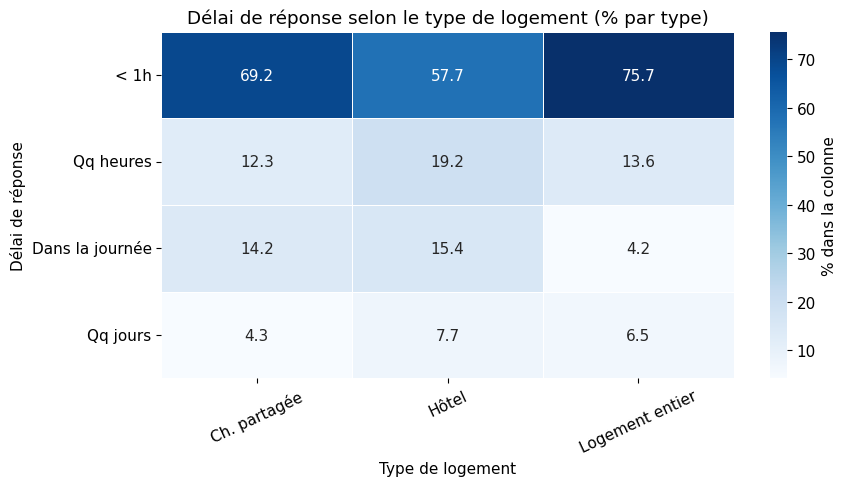

LIMITES : petits effectifs possibles dans certaines cases —
  une case à 100% avec n=3 ne signifie rien de général.

✅ Bloc C terminé — 5 graphiques sauvegardés.


In [2]:
# ============================================================
# BLOC C — Croisements — ImmoVision 360 (AUTONOME)
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f9f9f9",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})

# ============================================================
# ÉTAPE 0 — Connexion et reconstruction du DataFrame df
# ============================================================
conn = psycopg2.connect(
    host     = os.getenv("DB_HOST"),
    dbname   = os.getenv("DB_NAME"),
    user     = os.getenv("DB_USER"),
    password = os.getenv("DB_PASSWORD"),
    port     = os.getenv("DB_PORT"),
)

query = "SELECT * FROM elysee_tabular;"
df_raw = pd.read_sql(query, conn)
conn.close()

df = df_raw.fillna(-1)   # −1 = information non disponible
print(f"✅ DataFrame prêt : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# ============================================================
# Mappings lisibles
# ============================================================
ROOM_LABELS  = {-1:"Non dispo", 0:"Ch. privée",
                 1:"Logement entier", 2:"Ch. partagée", 3:"Hôtel"}
SCORE_LABELS = {-1:"Non dispo", 0:"Neutre", 1:"Positif"}
TIME_LABELS  = {-1:"Non dispo", 0:"< 1h",
                 1:"Qq heures", 2:"Dans la journée", 3:"Qq jours"}

# ============================================================
# CROISEMENT 1 — Concentration de l'offre
# ============================================================
print("\n=== Croisement 1 — Concentration de l'offre ===")

col = "calculated_host_listings_count"
s   = df[col][df[col] >= 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(s, bins=40, color="#4A90D9", edgecolor="white", linewidth=0.5)
ax1.set_title("Distribution : annonces par hôte")
ax1.set_xlabel("Nombre d'annonces")
ax1.set_ylabel("Fréquence")

sorted_s = s.sort_values()
cum_pct  = [i / len(sorted_s) * 100 for i in range(len(sorted_s))]
ax2.plot(sorted_s.values, cum_pct, color="#E07B54", linewidth=1.8)
ax2.set_title("Fréquence cumulée")
ax2.set_xlabel("Annonces par hôte")
ax2.set_ylabel("% des hôtes")
ax2.axhline(80, color="gray", linestyle="--", linewidth=0.8)
ax2.text(sorted_s.max() * 0.5, 82, "80 %", color="gray", fontsize=9)

plt.suptitle("Croisement 1 — Concentration de l'offre", fontweight="bold")
plt.tight_layout()
plt.savefig("croisement1_concentration.png", dpi=150)
plt.show()

print(f"  Médiane : {s.median()} annonces/hôte")
print(f"  Max     : {s.max()} annonces/hôte")
print(f"  Hôtes avec > 1 annonce : {(s > 1).mean()*100:.1f}%")
print("LIMITES : un hôte multi-annonces n'est pas forcément une agence.")

# ============================================================
# CROISEMENT 2 — Disponibilité × Score de standardisation
# ============================================================
print("\n=== Croisement 2 — Disponibilité × Score catalogue ===")

mask = (df["availability_365"] >= 0) & (df["standardization_score"] >= 0)
df2  = df[mask].copy()
df2["score_label"] = df2["standardization_score"].map(SCORE_LABELS)

order = ["Neutre", "Positif"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data    = df2,
    x       = "score_label",
    y       = "availability_365",
    order   = order,
    palette = {"Neutre":"#5B9BD5", "Positif":"#E07B54"},
    width   = 0.5,
    ax      = ax
)
ax.set_title("Disponibilité annuelle selon le score de standardisation")
ax.set_xlabel("Score de standardisation")
ax.set_ylabel("Jours disponibles / 365")

for i, grp in enumerate(order):
    n = df2[df2["score_label"] == grp].shape[0]
    ax.text(i, -15, f"n={n}", ha="center", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("croisement2_dispo_x_score.png", dpi=150)
plt.show()

for grp in order:
    med = df2[df2["score_label"] == grp]["availability_365"].median()
    print(f"  Médiane disponibilité — {grp} : {med} jours")
print("LIMITES : un facteur commun (type de bien) peut expliquer les deux.")

# ============================================================
# CROISEMENT 3 — Réactivité × Taille du portefeuille
# ============================================================
print("\n=== Croisement 3 — Réactivité × Nombre d'annonces ===")

mask = (
    (df["host_response_rate_num"]         >= 0) &
    (df["calculated_host_listings_count"] >= 0) &
    (df["room_type_code"]                 >= 0)
)
df3 = df[mask].copy()
df3["room_label"] = df3["room_type_code"].map(ROOM_LABELS)

palette = {
    "Ch. privée"     : "#4A90D9",
    "Logement entier": "#E07B54",
    "Ch. partagée"   : "#6BAF92",
    "Hôtel"          : "#9B79C8",
}

fig, ax = plt.subplots(figsize=(9, 5))
for label, group in df3.groupby("room_label"):
    ax.scatter(
        group["host_response_rate_num"],
        group["calculated_host_listings_count"],
        alpha=0.35, s=18,
        color=palette.get(label, "#AAAAAA"),
        label=label
    )
ax.set_title("Réactivité de l'hôte vs nombre d'annonces")
ax.set_xlabel("Taux de réponse (%)")
ax.set_ylabel("Nombre d'annonces par hôte")
ax.legend(title="Type de logement", fontsize=9)
plt.tight_layout()
plt.savefig("croisement3_reactivite_x_annonces.png", dpi=150)
plt.show()
print("LIMITES : les plateformes imposent des délais stricts indépendamment")
print("  du nb d'annonces — facteur commun possible.")

# ============================================================
# CROISEMENT 4 — Type de logement × Impact quartier
# ============================================================
print("\n=== Croisement 4 — Type de logement × Impact quartier ===")

mask = (df["room_type_code"] >= 0) & (df["neighborhood_impact_score"] >= 0)
df4  = df[mask].copy()
df4["room_label"]  = df4["room_type_code"].map(ROOM_LABELS)
df4["score_label"] = df4["neighborhood_impact_score"].map(SCORE_LABELS)

ct = pd.crosstab(
    df4["room_label"],
    df4["score_label"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(9, 5))
ct[["Neutre", "Positif"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=["#5B9BD5", "#E07B54"], edgecolor="white"
)
ax.set_title("Impact sur le quartier selon le type de logement (%)")
ax.set_xlabel("Type de logement")
ax.set_ylabel("% des annonces")
ax.set_ylim(0, 110)
ax.legend(title="Impact quartier", bbox_to_anchor=(1, 1))
ax.tick_params(axis="x", rotation=25)

totals = df4["room_label"].value_counts()
for i, room in enumerate(ct.index):
    ax.text(i, 103, f"n={totals.get(room,0)}",
            ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("croisement4_type_x_impact.png", dpi=150)
plt.show()
print("LIMITES : le score mesure le discours de l'hôte, pas l'impact réel")
print("  sur les loyers ou la population du quartier.")

# ============================================================
# CROISEMENT 5 — Délai de réponse × Type de logement
# ============================================================
print("\n=== Croisement 5 — Délai de réponse × Type de logement ===")

mask = (df["host_response_time_code"] >= 0) & (df["room_type_code"] >= 0)
df5  = df[mask].copy()
df5["room_label"] = df5["room_type_code"].map(ROOM_LABELS)
df5["time_label"] = df5["host_response_time_code"].map(TIME_LABELS)

time_order = ["< 1h", "Qq heures", "Dans la journée", "Qq jours"]
ct5 = pd.crosstab(
    df5["time_label"],
    df5["room_label"],
    normalize="columns"
) * 100
ct5 = ct5.reindex([t for t in time_order if t in ct5.index])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    ct5, annot=True, fmt=".1f", cmap="Blues",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "% dans la colonne"}
)
ax.set_title("Délai de réponse selon le type de logement (% par type)")
ax.set_xlabel("Type de logement")
ax.set_ylabel("Délai de réponse")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig("croisement5_delai_x_type.png", dpi=150)
plt.show()
print("LIMITES : petits effectifs possibles dans certaines cases —")
print("  une case à 100% avec n=3 ne signifie rien de général.")

print("\n✅ Bloc C terminé — 5 graphiques sauvegardés.")

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

dbname = os.getenv("DB_NAME")

print(f"\nRappel : pour la suite, utilisez la variable 'dbname' = '{dbname}'")

ModuleNotFoundError: No module named 'dotenv'